Loaded bare ansatz: 8 qubits, 3 params, 3 RZX, 3 cross-chip 2Q gates  (HF_8q_3doubles_rzx.json)
0: ───Rx(0.5π)───@──────────────────────────────────────────────────@───Rx(-0.5π)───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
                 │                                                  │
1: ───H──────────@───H───@──────────────────────────────────@───H───@───H───────────Rx(0.5π)───@──────────────────────────────@───Rx(-0.5π)─────────────────────────────────────────────────────────────────
                         │                                  │                                  │                              │
2: ───H──────────────────@───@───────X──────────────────────@──────────────────────────────────@───X──────────────────────@───@───H───────────Rx(0.5π)───H───@───X──────────────────────@───H───Rx(-0.5π)───
                             │       │                                                     

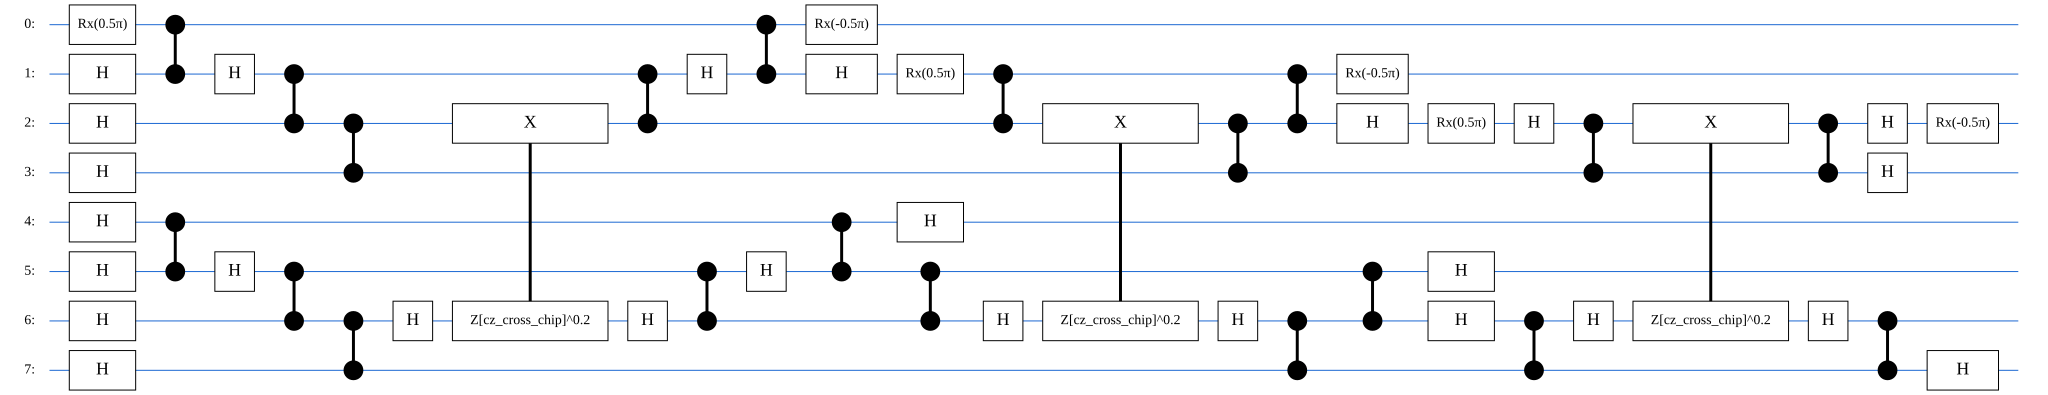

In [ ]:
# This cell is to read the circuit from the file 
# and set up some basic parameters and mole
from __future__ import annotations

import cirq
import numpy as np
from cirq.ops import GlobalPhaseGate

# Needed for text/SVG diagrams: top-level ``cirq.GlobalPhaseGate`` can be missing in some kernels.
setattr(cirq, "GlobalPhaseGate", GlobalPhaseGate)
import sympy
from IPython.display import display

from cirq.contrib.svg import SVGCircuit

# Shared sampling/CDR settings used across later notebook cells.
GLOBAL_NUM_SHOTS = 8192 # 8192
GLOBAL_RANDOM_SEED = 1234
GLOBAL_SAMPLING_SEED = 1234
GLOBAL_MEASUREMENT_SCHEME = "ogm"
GLOBAL_APPLY_READOUT_NOISE = True
GLOBAL_READOUT_P0_SUCCESS = np.array([0.97, 0.96, 0.93, 0.96, 0.92, 0.93, 0.94, 0.92])
GLOBAL_READOUT_P1_SUCCESS = np.array([0.85, 0.90, 0.88, 0.90, 0.86, 0.89, 0.87, 0.85])


import json
from pathlib import Path

# Which molecule / bond length to load. The circuit JSON is produced by the
# molecule notebook (e.g. UCCSD_Mole/HF.ipynb) via uccsd_circuit_io.build_and_save.
MOLECULE = "HF"
BOND_LENGTH = 1.2
bond_length = BOND_LENGTH  # alias used by later cells (OGM / Hamiltonian paths)

# Active space for the loaded molecule. These MUST match the molecule notebook
# that produced the circuit / Hamiltonian (e.g. UCCSD_Mole/HF.ipynb uses 6
# electrons in 4 spatial orbitals for HF). They drive the HF-determinant
# reference and the qubit-count sanity checks below.
N_ACTIVE_ELECTRONS = 6              # active electrons
N_SPATIAL_ORBITALS = 4             # active spatial orbitals
N_QUBITS = 2 * N_SPATIAL_ORBITALS  # spin-orbitals == qubits
ETA = N_ACTIVE_ELECTRONS // 2      # occupied spatial orbitals per spin sector

_repo = Path.cwd().resolve()
while not (_repo / "June_main").is_dir() and _repo != _repo.parent:
    _repo = _repo.parent
CIRCUITS_DIR = _repo / "June_main" / "circuits2read"

# Make the shared library importable from this first cell (later cells repeat this).
import sys as _sys
for _p in (
    str(_repo / "June_main" / "ML_CDR" / "ML_CDR_together"),
    str(_repo / "June_main"),
    str(_repo),
):
    if _p not in _sys.path:
        _sys.path.insert(0, _p)
# Parameterized native cross-chip RZX gate (supports sympy angles + resolution and
# is recognized by the CDR Clifford-snapping in main_cursor_lib).
from main_cursor_lib_ML_tog import RZXGate
# Bare ansatz (NO initial-state prep), with cross-chip CZ already decomposed to
# the native RZX form. The reference state (HF / multireference) is prepended in
# the next cell, so this cell just reads + draws the ansatz to confirm it loaded.
CIRCUIT_NAME = "HF_8q_3doubles_rzx"
CIRCUIT_JSON = CIRCUITS_DIR / f"{CIRCUIT_NAME}.json"

# Cross-chip two-qubit gates carry this tag so the noise model can apply a higher
# (cross-chip) depolarizing probability.
CZ_CROSS_CHIP_TAG = "cz_cross_chip"

# Which qubit pairs physically span two chips. The circuit JSON no longer carries
# a per-gate "cross_chip" flag; instead, ANY two-qubit gate acting on one of these
# (qubit_i, qubit_j) line-qubit index pairs is treated as a cross-chip link and
# gets the higher CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB noise. Order does not
# matter: (3, 4) and (4, 3) are the same link. Edit this to match the chip layout.
# In HF_8q_3doubles_rzx.json the native RZX entanglers act on qubits 2 and 6, so
# that is the cross-chip link here.
CROSS_CHIP_QUBIT_PAIRS = {(2, 6)}
_CROSS_CHIP_PAIR_SET = {frozenset(pair) for pair in CROSS_CHIP_QUBIT_PAIRS}


def _is_cross_chip_pair(qubit_indices):
    """True if the (unordered) qubit-index pair is a configured cross-chip link."""
    return frozenset(qubit_indices) in _CROSS_CHIP_PAIR_SET


def load_circuit_from_json(path):
    """Build a cirq.Circuit (LineQubit layout) from a saved UCCSD circuit JSON.

    Returns (circuit, qubits, symbols, meta). ANY two-qubit gate (CZ, RZX, CX, ...)
    whose qubit pair is listed in ``CROSS_CHIP_QUBIT_PAIRS`` is tagged with
    ``CZ_CROSS_CHIP_TAG`` so it gets the higher cross-chip depolarizing noise.
    Parameterized RX/RZ/RZX angles use sympy symbols named ``th_<k>`` so the CDR
    Clifford-snapping in ``main_cursor_lib`` treats them as theta-like.
    """
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    n = int(data["num_qubits"])
    q = cirq.LineQubit.range(n)
    param_names = list(data["param_names"])
    # Some circuit JSONs (e.g. the RZX-native variant) leave ``param_names`` empty
    # but still reference params (``"param": "t0"``) on their gates. Recover the
    # parameter list from gate references, in order of first appearance.
    if not param_names:
        for g in data["gates"]:
            name = g.get("param")
            if name is not None and name not in param_names:
                param_names.append(name)
    sym = {name: sympy.Symbol(f"th_{i}") for i, name in enumerate(param_names)}
    syms = [sym[name] for name in param_names]

    c = cirq.Circuit()
    for g in data["gates"]:
        op = g["op"]
        qs = [q[i] for i in g["qubits"]]
        if op == "h":
            new_op = cirq.H(qs[0])
        elif op == "x":
            new_op = cirq.X(qs[0])
        elif op == "ry":
            new_op = cirq.ry(float(g["value"])).on(qs[0])
        elif op == "cx":
            new_op = cirq.CNOT(qs[0], qs[1])
        elif op == "cz":
            new_op = cirq.CZ(qs[0], qs[1])
        elif op == "rzx":
            # Native cross-chip gate kept as ONE 2-qubit op. The angle can be a
            # sympy symbol (parameterized ansatz) and is resolved later for VQE,
            # gradients and CDR -- just like the single-qubit rx/rz rotations.
            if "param" in g:
                rzx_angle = float(g.get("coeff", 1.0)) * sym[g["param"]]
            else:
                rzx_angle = float(g.get("angle", g.get("value", 0.0)))
            new_op = RZXGate(rzx_angle).on(qs[0], qs[1])
        elif op in ("rx", "rz"):
            angle = float(g["coeff"]) * sym[g["param"]] if "param" in g else float(g["value"])
            gate = cirq.rx if op == "rx" else cirq.rz
            new_op = gate(angle).on(qs[0])
        else:
            raise ValueError(f"Unhandled op in circuit JSON: {op!r}")

        # Gate-agnostic cross-chip tagging: ANY two-qubit gate (CZ, RZX, CX, ...)
        # acting on a cross-chip pair gets the tag, so the noise model applies the
        # higher CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB. The noise model only cares
        # that the op is 2-qubit and carries the tag -- not which gate it is.
        if len(new_op.qubits) == 2 and _is_cross_chip_pair(g["qubits"]):
            new_op = new_op.with_tags(CZ_CROSS_CHIP_TAG)
        c.append(new_op)
    return c, list(q), syms, data


circuit, qubits, symbols, circuit_meta = load_circuit_from_json(CIRCUIT_JSON)
# Bare ansatz handle: the next cell prepends the reference-state prep and rebinds
# ``circuit`` to (prep + ansatz). Keeping this separate makes that step idempotent.
ansatz_circuit = circuit
num_qubits = len(qubits)
n_params = len(symbols)
qubit_map = {qq: i for i, qq in enumerate(qubits)}

# Sanity-check the loaded circuit against the declared active space.
assert num_qubits == N_QUBITS, (
    f"Circuit has {num_qubits} qubits but active space implies "
    f"N_QUBITS={N_QUBITS} (= 2 * N_SPATIAL_ORBITALS={N_SPATIAL_ORBITALS})."
)
_meta_ne = circuit_meta.get("n_electrons")
if _meta_ne is not None:
    assert int(_meta_ne) == N_ACTIVE_ELECTRONS, (
        f"Circuit JSON n_electrons={int(_meta_ne)} != "
        f"N_ACTIVE_ELECTRONS={N_ACTIVE_ELECTRONS}."
    )


def resolver_from_params(params_vec):
    """Map a length-``n_params`` vector to a {symbol: value} resolver dict."""
    p = np.asarray(params_vec, dtype=float).reshape(n_params)
    return {symbols[i]: float(p[i]) for i in range(n_params)}


# Backward-compatible aliases for cells originally written for the 3-parameter LiH case.
symbols_li_h = symbols
if n_params >= 1:
    theta1 = symbols[0]
if n_params >= 2:
    theta2 = symbols[1]
if n_params >= 3:
    theta3 = symbols[2]

_n_cross = sum(
    1 for g in circuit_meta["gates"]
    if len(g["qubits"]) == 2 and _is_cross_chip_pair(g["qubits"])
)
_n_rzx = sum(1 for g in circuit_meta["gates"] if g["op"] == "rzx")
print(
    f"Loaded bare ansatz: {num_qubits} qubits, {n_params} params, "
    f"{_n_rzx} RZX, {_n_cross} cross-chip 2Q gates  ({CIRCUIT_JSON.name})"
)

# Diagram at θ = π/5 on every parameter (visualization only).
_theta_viz = np.pi / 5
resolver_viz = cirq.ParamResolver({s: _theta_viz for s in symbols})
circuit_draw = cirq.resolve_parameters(circuit, resolver_viz)

print(circuit_draw)
display(SVGCircuit(circuit_draw))

# --- Qiskit-style diagram (matches "UCCSD circuit/br2_16q_3doubles_circuit.png") ---
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit as _QiskitCircuit

# Qiskit "iqp" colours hard-coded so the look matches regardless of qiskit version:
# salmon H, blue X, maroon rotations, light-blue CZ links.
_IQP_STYLE = {
    "name": "iqp",
    "displaycolor": {
        "h": ["#FA4D56", "#000000"],
        "x": ["#002D9C", "#FFFFFF"],
        "rx": ["#9F1853", "#FFFFFF"],
        "ry": ["#9F1853", "#FFFFFF"],
        "rz": ["#33B1FF", "#000000"],
        "rzx": ["#33B1FF", "#000000"],
        "cz": ["#33B1FF", "#000000"],
        "cx": ["#002D9C", "#000000"],
    },
}


from qiskit.circuit import Parameter as _QiskitParameter


def _qiskit_circuit_from_meta(meta):
    # SAME code as the circuit generator's save_circuit_diagram /
    # qc_from_logical_gates: symbolic rotations keep their parameter name
    # (t0, t1, ...), so the look matches the PNGs saved in circuits2read
    # (e.g. HF_8q_3doubles_circuit.png).
    qcq = _QiskitCircuit(int(meta["num_qubits"]))
    _params: dict = {}

    def _angle(g):
        if "param" in g:
            p = _params.setdefault(g["param"], _QiskitParameter(g["param"]))
            return float(g.get("coeff", 1.0)) * p
        return float(g.get("value", g.get("angle", 0.0)))

    for g in meta["gates"]:
        op = g["op"].lower()
        qb = g["qubits"]
        if op == "x":
            qcq.x(qb[0])
        elif op == "h":
            qcq.h(qb[0])
        elif op == "cx":
            qcq.cx(qb[0], qb[1])
        elif op == "cz":
            qcq.cz(qb[0], qb[1])
        elif op == "rx":
            qcq.rx(_angle(g), qb[0])
        elif op == "ry":
            qcq.ry(_angle(g), qb[0])
        elif op == "rz":
            qcq.rz(_angle(g), qb[0])
        elif op == "rzx":
            qcq.rzx(_angle(g), qb[0], qb[1])
        else:
            raise ValueError(f"Unhandled op in circuit JSON: {op!r}")
    return qcq


_qcq = _qiskit_circuit_from_meta(circuit_meta)
# fold=-1 -> one continuous row (no wrapping), matching the reference PNG layout.
_fig = _qcq.draw(output="mpl", style=_IQP_STYLE, fold=-1)
_fig.suptitle(f"{CIRCUIT_NAME}", fontsize=14)
plt.show()

In [2]:
# =====================================================================
# Combined CDR + GP (single-GP) error-mitigator hyperparameters  (TUNE THESE)
# =====================================================================
# This is the single place to tune the new error-mitigation method. The cells
# after the REM section build a gp_mitigator_ML_tog.MitigatorConfig straight
# from these values, so you can run the whole notebook top-to-bottom to assess
# the method's performance.
import numpy as np

# --- Warm-start near-Clifford data generation (fits the single combined GP) ---
GP_N_WARMSTART_CIRCUITS  = 10    # more circuits -> cover all 3 angle dims well even with 2 non-Clifford/circuit
GP_N_NONCLIFFORD_GATES   = 2     # params kept non-Clifford per circuit; coverage now comes from MORE circuits + WIDER spread
GP_WARMSTART_SPREAD      = 0.8   # rad: WIDER jitter so training samples intermediate <P> (not just stabilizer ±1/0); still covers VQE region (~0.45)
GP_SHOTS                 = 1 * int(GLOBAL_NUM_SHOTS)   # shots per circuit / observable (2x -> lower per-Pauli noise floor)
GP_THETA_INIT            = None  # None -> all-zero (reference state); else list[n_params]

# --- Feature encoding (GP inputs) ---
GP_MAX_HARMONIC          = 2     # Fourier harmonics of the angles (1 or 2 typical)
GP_INCLUDE_NOISY_FEATURE = True  # feed O_noisy as a GP feature
GP_PAULI_ONEHOT          = True  # per-qubit {I,X,Y,Z} one-hot features
GP_PAULI_SUMMARIES       = True  # [weight, n_XY, n_Z] summary features

# --- Baseline per-Pauli CDR (reference only; the CDR line lives in the GP kernel) ---
GP_AFFINE_REGULARIZATION = 0.0   # ridge on the per-Pauli slope (0 = plain LS)
GP_REFIT_AFFINE_ON_TOPUP = True  # refit (a_i, b_i) when new rows arrive

# --- Combined single-GP kernel (CDR absorbed in the kernel) ---
GP_KERNEL_TYPE           = "matern"  # "matern" or "rbf"
GP_MATERN_NU             = 2.5       # Matern smoothness (0.5, 1.5, 2.5)
GP_USE_ARD               = True      # per-dimension length scales
GP_USE_PRODUCT_KERNEL    = True      # in-kernel CDR x per-observable kernel (per-Pauli slope)
GP_NOISE_VARIANCE_INIT   = 1e-3      # WhiteKernel init (learned shot noise)
GP_NORMALIZE_TARGETS     = True
GP_N_RESTARTS            = 2          # GP marginal-likelihood restarts
GP_MAX_TRAIN_POINTS      = 600     # use more of the warm-start rows for the exact GP (was 500 -> off-path under-coverage)

# --- Top-up controller (online refinement during VQE) ---
# A top-up is taken EVERY iteration (GP_TOPUP_EVERY = 1), so the uncertainty-gate
# and trust-region (move) triggers are unnecessary and left at their library
# defaults in gp_mitigator_ML_tog.MitigatorConfig.
GP_TOPUP_EVERY           = 1     # mandatory top-up cadence (1 = one top-up per iteration)
GP_TOPUP_BATCH_SIZE      = 10    # near-Clifford circuits added per top-up
GP_TOPUP_RADIUS          = 0.5   # rad: top-ups sample intermediate angles locally
GP_DROP_FARAWAY_POINTS   = True  # prune rows far from the current theta
GP_MAX_GP_POINTS         = GP_MAX_TRAIN_POINTS # row budget kept for the GP
# Convergence validation: when |grad| < GP_CONVERGENCE_GRAD_TOL, fire one REAL
# near-Clifford top-up at theta and only stop if the energy then moves < tol.
# Set GP_CONVERGENCE_GRAD_TOL = 0.0 to disable early stopping (run full budget).
GP_CONVERGENCE_GRAD_TOL  = 5e-3
GP_CONVERGENCE_ENERGY_TOL = 1e-3  # Eh: max E_mit shift after the validation top-up

# --- VQE optimizer (matches June_main/main_HF.ipynb: parameter-shift + fixed LR) ---
GP_VQE_ITERS             = 15   # VQE iterations (10 to actually converge; matches main_HF.ipynb)
GP_LEARNING_RATE         = 0.5   # fixed learning rate (matches main_HF.ipynb VQE_LR; full theta - lr*grad update)
GP_OPTIMIZER_STEP_MAX    = 0.2   # local radius for uncertainty-gated top-ups (the VQE step is NOT clipped, like main_HF)
GP_FD_EPS                = 0.05  # only used if gradient_mode='finite_difference' (main_HF uses parameter-shift)

# --- Validation / RNG ---
GP_HOLDOUT_FRACTION      = 0.2
GP_RNG_SEED              = int(GLOBAL_SAMPLING_SEED)

print("Combined CDR+GP (single-GP) hyperparameters set. Edit THIS cell to tune the method.")


Combined CDR+GP (single-GP) hyperparameters set. Edit THIS cell to tune the method.


In [3]:
import sys
from pathlib import Path

# Repo root resolution for local file loading (root holds Pauli_Ham/ and June_main/).
_repo = Path.cwd().resolve()
while not (_repo / "Pauli_Ham").is_dir() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (str(_repo / "June_main"), str(_repo)):
    if _p not in sys.path:
        sys.path.insert(0, _p)


# Read numbered-Pauli Hamiltonian from Pauli_Ham/<MOLECULE>_bond_<bond>.txt.
def load_pauli_sum_from_numbered_file(path: Path, qubits: list[cirq.Qid]) -> cirq.PauliSum:
    idx_to_pauli = {1: cirq.X, 2: cirq.Y, 3: cirq.Z}
    out = cirq.PauliSum()

    with path.open("r", encoding="utf-8") as f:
        for lineno, raw in enumerate(f, start=1):
            line = raw.strip()
            if not line:
                continue

            parts = line.split()
            coeff = float(parts[0])
            pauli_codes = [int(x) for x in parts[1:]]

            if len(pauli_codes) != len(qubits):
                raise ValueError(
                    f"{path}:{lineno} has {len(pauli_codes)} Pauli indices, expected {len(qubits)}."
                )

            pauli_string = cirq.PauliString()
            for q, code in zip(qubits, pauli_codes):
                if code == 0:
                    continue
                if code not in idx_to_pauli:
                    raise ValueError(f"{path}:{lineno} has invalid Pauli code {code}; expected 0/1/2/3.")
                pauli_string *= idx_to_pauli[code](q)

            out += coeff * pauli_string

    return out


ham_path = _repo / "Pauli_Ham" / f"{MOLECULE}_bond_{bond_length:.1f}.txt"

# Hamiltonian + exact ground-state energy. The bare ansatz (no prep) is not a
# meaningful state by itself, so the reference energy of the FULL circuit is
# reported in the "Initial state preparation" cell once the prep is prepended.
pauli_sum = load_pauli_sum_from_numbered_file(ham_path, list(qubits))
qubit_map = {q: i for i, q in enumerate(qubits)}
e_gs = float(np.linalg.eigvalsh(pauli_sum.matrix(qubits=qubits))[0].real)

# HF determinant reference (X on the occupied spin-orbitals of this active
# space). Occupation comes from the explicit active-space inputs above
# (N_ACTIVE_ELECTRONS / N_SPATIAL_ORBITALS), not the circuit metadata.
_half = N_SPATIAL_ORBITALS
_eta = ETA
_occ = list(range(_eta)) + list(range(_half, _half + _eta))
psi_hf = cirq.Simulator().simulate(
    cirq.Circuit([cirq.X(qubits[k]) for k in _occ] or [cirq.I(q) for q in qubits]),
    qubit_order=qubits,
).final_state_vector
e_hf_ref = float(
    np.real(pauli_sum.expectation_from_state_vector(np.asarray(psi_hf, dtype=np.complex128), qubit_map=qubit_map))
)

print(
    f"\n{MOLECULE} bond {bond_length} Å  "
    f"(active space: {N_ACTIVE_ELECTRONS}e, {N_SPATIAL_ORBITALS}o -> {N_QUBITS} qubits)"
)
print(f"Hamiltonian source: {ham_path}")
print(f"⟨H⟩ HF determinant reference: {e_hf_ref:.10f} Eh")
print(f"Ground-state energy e_gs (exact): {e_gs:.10f} Eh")


HF bond 1.2 Å  (active space: 6e, 4o -> 8 qubits)
Hamiltonian source: /Users/zacharyhe/cross_chips_sim/Pauli_Ham/HF_bond_1.2.txt
⟨H⟩ HF determinant reference: -98.5230711309 Eh
Ground-state energy e_gs (exact): -98.5738783367 Eh


In [4]:
# === Initial state preparation: HF (default) or multireference ======
# Prepend the reference state to the bare ansatz loaded above, then rebind
# ``circuit`` to the full (prep + ansatz) circuit used by every later cell.
#   "hf"       -> Hartree-Fock determinant (X on the occupied spin-orbitals)
#   "multiref" -> paper Eq.(6) state (|HF> - beta|exc>)/sqrt(1+beta^2). The prep
#                 rotation Ry(alpha = -2*arctan(beta)) is optimized HERE by
#                 minimizing the noiseless <H> (no separate set-then-optimize).
INIT_STATE_METHOD = "hf"  # "hf" or "multiref"

from scipy.optimize import minimize_scalar

_half = N_SPATIAL_ORBITALS
_eta = ETA
_occupied = list(range(_eta)) + list(range(_half, _half + _eta))
_sim_prep = cirq.Simulator()


def hf_prep_circuit() -> cirq.Circuit:
    """HF determinant: X on each occupied spin-orbital."""
    return cirq.Circuit([cirq.X(qubits[k]) for k in _occupied])


def multiref_prep_circuit(alpha: float) -> cirq.Circuit:
    """Paper Eqs.(7)-(8): Ry(alpha) on q_{eta-1}, a 3-CNOT chain, then the HF X layer."""
    c = cirq.Circuit()
    c.append(cirq.ry(float(alpha)).on(qubits[_eta - 1]))
    c.append(cirq.CNOT(qubits[_eta - 1], qubits[_eta]))
    c.append(cirq.CNOT(qubits[_eta], qubits[_half + _eta - 1]))
    c.append(cirq.CNOT(qubits[_half + _eta - 1], qubits[_half + _eta]))
    c.append([cirq.X(qubits[k]) for k in _occupied])
    return c


def _prep_state_energy(prep: cirq.Circuit) -> float:
    psi = np.asarray(
        _sim_prep.simulate(prep, qubit_order=qubits).final_state_vector, dtype=np.complex128
    )
    return float(np.real(pauli_sum.expectation_from_state_vector(psi, qubit_map=qubit_map)))


if INIT_STATE_METHOD == "hf":
    prep_circuit = hf_prep_circuit()
    multiref_alpha = None
    multiref_beta = None
    print("Initial state: Hartree-Fock determinant")
    print(f"  occupied spin-orbitals : {_occupied}")
elif INIT_STATE_METHOD == "multiref":
    # Combined choice + optimization: minimize <H> over the prep rotation alpha.
    _opt = minimize_scalar(
        lambda a: _prep_state_energy(multiref_prep_circuit(a)),
        bounds=(-np.pi, np.pi),
        method="bounded",
    )
    multiref_alpha = float(_opt.x)
    multiref_beta = float(-np.tan(multiref_alpha / 2.0))
    prep_circuit = multiref_prep_circuit(multiref_alpha)
    print("Initial state: multireference (paper Eq.6), beta optimized in this cell")
    print(f"  optimal alpha = {multiref_alpha:.6f} rad  ->  beta = {multiref_beta:.6f}")
else:
    raise ValueError(f"INIT_STATE_METHOD must be 'hf' or 'multiref', got {INIT_STATE_METHOD!r}")

# Full circuit = prep + bare ansatz. Rebuilt from ``ansatz_circuit`` every run so
# re-executing this cell is idempotent; rebind ``circuit`` for downstream cells.
circuit = prep_circuit + ansatz_circuit
n_params = len(symbols)  # prep adds no free parameters

# Reference energy of the full circuit at theta = 0 (= the chosen prep state).
_res0 = cirq.resolve_parameters(circuit, cirq.ParamResolver({s: 0.0 for s in symbols}))
_psi0 = np.asarray(
    cirq.Simulator().simulate(_res0, qubit_order=qubits).final_state_vector, dtype=np.complex128
)
e_prep_ref = float(np.real(pauli_sum.expectation_from_state_vector(_psi0, qubit_map=qubit_map)))

print(f"  ⟨H⟩ prep state (all θ=0)  : {e_prep_ref:.10f} Eh")
print(f"  ⟨H⟩ HF determinant ref    : {e_hf_ref:.10f} Eh")
print(f"  ground-state e_gs (exact) : {e_gs:.10f} Eh")
print(
    f"Full circuit ready: {len(list(circuit.all_operations()))} ops, "
    f"{n_params} params (downstream cells use `circuit`)."
)

Initial state: Hartree-Fock determinant
  occupied spin-orbitals : [0, 1, 2, 4, 5, 6]
  ⟨H⟩ prep state (all θ=0)  : -98.5230711309 Eh
  ⟨H⟩ HF determinant ref    : -98.5230711309 Eh
  ground-state e_gs (exact) : -98.5738783367 Eh
Full circuit ready: 61 ops, 3 params (downstream cells use `circuit`).


In [5]:
# Evaluate the compiled ansatz energy at the noiseless L-BFGS-B optimum
# (June_main/optimize_hf_3doubles_lbfgs.py, HF bond 2.2, Hartree-Fock prep).
params = np.array([0.0020292770, 0.0020329417, -4.9689013693], dtype=float)
resolver_test = cirq.ParamResolver(resolver_from_params(params))

resolved_test = cirq.resolve_parameters(circuit, resolver_test)
psi_test = np.asarray(
    cirq.Simulator(dtype=np.complex128).simulate(resolved_test, qubit_order=qubits).final_state_vector,
    dtype=np.complex128,
)
e_test = float(np.real(pauli_sum.expectation_from_state_vector(psi_test, qubit_map=qubit_map)))

print(f"params = {params.tolist()}")
print(f"E(params) = {e_test:.10f} Eh")

params = [0.002029277, 0.0020329417, -4.9689013693]
E(params) = -98.2057450856 Eh


In [6]:
# No measurement error here (density matrix + Tr[H ρ]).
# just noisy energy using trace of H * rho 
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (
    str(_repo / "June_main" / "ML_CDR" / "ML_CDR_together"),
    str(_repo / "June_main"),
    str(_repo),
):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from main_cursor_lib_ML_tog import (
    GateArityDepolarizingNoise,
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    trace_energy,
)

random_seed = int(globals()["GLOBAL_RANDOM_SEED"])

gate_noise = GateArityDepolarizingNoise(
    two_qubit_depol_prob=TWO_QUBIT_GATE_DEPOL_PROB,
    one_qubit_depol_prob=ONE_QUBIT_GATE_DEPOL_PROB,
    cross_chip_two_qubit_depol_prob=CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
)
noisy_ansatz = circuit.with_noise(gate_noise)
resolver_noisy = cirq.ParamResolver(resolver_from_params(params))
resolved_noisy = cirq.resolve_parameters(noisy_ansatz, resolver_noisy)

rho_noisy = np.asarray(
    cirq.DensityMatrixSimulator(seed=random_seed)
    .simulate(resolved_noisy, qubit_order=qubits)
    .final_density_matrix,
    dtype=np.complex128,
)

hamiltonian_matrix = pauli_sum.matrix(qubits=qubits)
trace_noisy_energy = trace_energy(hamiltonian_matrix, rho_noisy)

print(
    f"noise: two_qubit_depol={gate_noise.two_qubit_depol_prob} "
    f"one_qubit_depol={gate_noise.one_qubit_depol_prob} "
    f"cross_chip_two_qubit_depol={gate_noise.cross_chip_two_qubit_depol_prob}"
)
print(f"params = {params.tolist()}")
print(f"Tr[H ρ_noisy] (gate noise only): {trace_noisy_energy:.10f} Eh")

noise: two_qubit_depol=0.005 one_qubit_depol=0.0001 cross_chip_two_qubit_depol=0.1
params = [0.002029277, 0.0020329417, -4.9689013693]
Tr[H ρ_noisy] (gate noise only): -97.8600090774 Eh


In [7]:
# Finite-shot energy from the same ``rho_noisy`` as above: OGM measurement layout + asymmetric
# readout (``p_0_success`` / ``p_1_success`` on LineQubit 0…5) and optional REM in post-processing.
# the OGM basis file is from the OGM_measurement_basis folder instead of old path from shadowgrouping folder
import sys
from pathlib import Path

_repo = Path.cwd().resolve()
while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
    _repo = _repo.parent
for _p in (
    str(_repo / "June_main" / "ML_CDR" / "ML_CDR_together"),
    str(_repo / "June_main"),
    str(_repo),
):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from shot_measurement_ML_tog import estimate_energy_from_noisy_rho_shots

num_shots = int(globals()["GLOBAL_NUM_SHOTS"])
measurement_scheme = str(globals()["GLOBAL_MEASUREMENT_SCHEME"])
sampling_seed = int(globals()["GLOBAL_SAMPLING_SEED"])
epsilon = 0.1

p_0_success = np.array(globals()["GLOBAL_READOUT_P0_SUCCESS"], dtype=float)
p_1_success = np.array(globals()["GLOBAL_READOUT_P1_SUCCESS"], dtype=float)

apply_readout_noise = bool(globals()["GLOBAL_APPLY_READOUT_NOISE"])
apply_rem = True

SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
ogm_file = globals().get(
    "ogm_file",
    _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
)

print(f"OGM file: {ogm_file}  exists={ogm_file.is_file()}")

if not ogm_file.is_file():
    print(
        "Skip OGM shot estimate: OGM file missing. Generate LiH OGM at this bond or set SHADOWGROUPING_ROOT."
    )
elif not Path(SHADOWGROUPING_ROOT).is_dir():
    print("Skip OGM shot estimate: SHADOWGROUPING_ROOT does not exist.")
else:
    try:
        shot_est = estimate_energy_from_noisy_rho_shots(
            rho_noisy,
            pauli_sum,
            qubits,
            num_shots=num_shots,
            measurement_scheme=measurement_scheme,
            p_0_success=p_0_success,
            p_1_success=p_1_success,
            apply_rem=apply_rem,
            apply_readout_noise=apply_readout_noise,
            sampling_seed=sampling_seed,
            epsilon=epsilon,
            ogm_file=ogm_file,
            shadowgrouping_root=SHADOWGROUPING_ROOT,
        )
        eu = float(shot_est["energy_unmitigated"])
        er = float(shot_est["energy_rem"])

        print(f"Finite-shot energy (readout noise, no REM correction): {eu:.12f} Eh")
        print(f"Finite-shot energy (REM readout mitigation):          {er:.12f} Eh")
        print(f"REM delta (REM - raw shots):                            {er - eu:.12f} Eh")
        print(
            f"\nReference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): {trace_noisy_energy:.12f} Eh"
        )
    except Exception:
        raise

OGM file: /Users/zacharyhe/cross_chips_sim/June_main/OGM_measurement_basis/OGM_HF_bond_1.2.txt  exists=True
Finite-shot energy (readout noise, no REM correction): -97.300489709989 Eh
Finite-shot energy (REM readout mitigation):          -97.892519674292 Eh
REM delta (REM - raw shots):                            -0.592029964303 Eh

Reference Tr[H ρ] (same ρ, exact Pauli from DM; no shot noise): -97.860009077350 Eh


In [8]:
# # Measurement error vs shot budget: mean(|REM - reference|) over independent shot seeds.
# import sys
# from pathlib import Path

# import matplotlib.pyplot as plt
# import numpy as np

# _repo = Path.cwd().resolve()
# while not (_repo / "June_main" / "main_cursor_lib.py").is_file() and _repo != _repo.parent:
#     _repo = _repo.parent
# for _p in (
#     str(_repo / "June_main" / "ML_CDR" / "ML_CDR_together"),
#     str(_repo / "June_main"),
#     str(_repo),
# ):
#     if _p not in sys.path:
#         sys.path.insert(0, _p)

# from shot_measurement_ML_tog import (
#     estimate_energy_from_noisy_rho_shots,
#     sanitize_density_matrix,
# )

# # Same shot/readout settings as the finite-shot cell above (LiH OGM + REM).
# measurement_scheme = str(globals().get("measurement_scheme", globals()["GLOBAL_MEASUREMENT_SCHEME"]))
# sampling_seed = int(globals().get("sampling_seed", globals()["GLOBAL_SAMPLING_SEED"]))
# epsilon = float(globals().get("epsilon", 0.1))
# p_0_success = np.array(globals().get("p_0_success", globals()["GLOBAL_READOUT_P0_SUCCESS"]), dtype=float)
# p_1_success = np.array(globals().get("p_1_success", globals()["GLOBAL_READOUT_P1_SUCCESS"]), dtype=float)
# apply_readout_noise = bool(globals().get("apply_readout_noise", globals()["GLOBAL_APPLY_READOUT_NOISE"]))
# apply_rem = bool(globals().get("apply_rem", True))

# SHADOWGROUPING_ROOT = globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping")
# ogm_file = globals().get(
#     "ogm_file",
#     _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
# )

# # Exact Tr[H rho_noisy] from the gate-noise DM cell (main.ipynb uses e_noisy_adj for the same role).
# energy_reference = float(globals()["trace_noisy_energy"])

# if not Path(ogm_file).is_file():
#     print(f"Skip shot-budget sweep: OGM file missing ({ogm_file}).")
# elif not Path(SHADOWGROUPING_ROOT).is_dir():
#     print("Skip shot-budget sweep: SHADOWGROUPING_ROOT does not exist.")
# else:
#     rho_noisy_for_shots = sanitize_density_matrix(rho_noisy)

#     shot_budgets = [
#         8192,
#         8192 * 2,
#         8192 * 4,
#         8192 * 10
#     ]
#     num_replicates = 20
#     base_seed = int(globals().get("GLOBAL_SAMPLING_SEED", sampling_seed))

#     mean_errors = []
#     std_errors = []
#     for n_shots in shot_budgets:
#         errs = []
#         for rep in range(num_replicates):
#             est = estimate_energy_from_noisy_rho_shots(
#                 rho_noisy_for_shots,
#                 pauli_sum,
#                 list(qubits),
#                 num_shots=int(n_shots),
#                 measurement_scheme=measurement_scheme,
#                 p_0_success=p_0_success,
#                 p_1_success=p_1_success,
#                 apply_rem=apply_rem,
#                 apply_readout_noise=apply_readout_noise,
#                 sampling_seed=base_seed + rep,
#                 epsilon=epsilon,
#                 ogm_file=ogm_file,
#                 shadowgrouping_root=SHADOWGROUPING_ROOT,
#             )
#             errs.append(abs(float(est["energy_rem"]) - energy_reference))
#         mean_errors.append(float(np.mean(errs)))
#         std_errors.append(float(np.std(errs, ddof=1)))
#         print(
#             f"n_shots={n_shots:7d}: mean(|REM-ref|)={mean_errors[-1]:.6e} Eh  "
#             f"std={std_errors[-1]:.6e} Eh"
#         )

#     fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=140)
#     ax.errorbar(
#         shot_budgets,
#         mean_errors,
#         yerr=std_errors,
#         fmt="o-",
#         capsize=4,
#         lw=2,
#         ms=7,
#         color="tab:blue",
#         label=f"mean over {num_replicates} seeds",
#     )
#     ax.axhline(0.0, color="0.45", ls="--", lw=1)
#     ax.set_xscale("log")
#     ax.set_xlabel("Number of shots")
#     ax.set_ylabel("|REM − reference| (Eh)")
#     ax.set_title("Finite-shot absolute measurement error vs shot budget")
#     ax.grid(True, alpha=0.3)
#     ax.legend(loc="best")
#     plt.tight_layout()
#     plt.show()

## Combined CDR + Gaussian-Process Error Mitigator (Design 2)

This section **replaces** the per-Pauli CDR / parameter-shift-VQE workflow above.
Instead of fitting a separate per-Pauli affine CDR and then a GP on its residual
(the two-stage *separate* design), here a **single Gaussian Process** maps the
feature row directly to the ideal expectation, with the classic CDR line absorbed
**inside the kernel**:

`O_mit(theta, P_i) = GP(features(theta, P_i, O_noisy))  ~=  O_ideal`

The kernel is `c_lin * k_lin(O_noisy) [* k_obs(P_i)] + c_base * k_base(angles, P_i) + white`:
the `k_lin` (DotProduct on `O_noisy`) term is the learned CDR slope/bias, `k_obs`
lets that slope vary per observable, and `k_base` (Matern/RBF) captures the
coherent, angle-dependent residual. A plain per-Pauli CDR is still fit, but only
as a **baseline** for the validation/plots.

The GP returns a variance per prediction, which drives an **uncertainty-gated
top-up** loop: a normal VQE iteration spends zero new circuits; only when the
`|c_i|`-weighted predicted std exceeds `uncertainty_threshold` do we sample a small
batch of **local** near-Clifford circuits, refit, and continue.

All knobs live in the **hyperparameter cell near the top** (the `GP_*` variables).
Measurement is always **OGM** — if the OGM basis file or the shadowgrouping backend
is missing, the mitigator raises (there is **no** per-Pauli fallback).

In [9]:
# === Combined CDR + GP (single-GP) mitigator: configuration + warm start ===
# Builds a gp_mitigator_ML_tog.MitigatorConfig straight from the GP_* hyperparameters
# (second cell), then fits ONE combined GP (CDR absorbed in the kernel) on a
# batch of LOCAL near-Clifford circuits. OGM measurement is
# mandatory: if the OGM basis / shadowgrouping backend is missing the adapter
# raises (no silent per-Pauli fallback).
import sys as _sys
import importlib
import warnings
from pathlib import Path as _Path
import numpy as np

_here = _Path.cwd().resolve()
_repo = _here
while not (_repo / "June_main").is_dir() and _repo != _repo.parent:
    _repo = _repo.parent
_ml_tog_dir = _repo / "June_main" / "ML_CDR" / "ML_CDR_together"
for _p in (str(_ml_tog_dir), str(_here), str(_repo / "June_main"), str(_repo)):
    if _p not in _sys.path:
        _sys.path.insert(0, _p)

import gp_mitigator_ML_tog as gpm
importlib.reload(gpm)
from main_cursor_lib_ML_tog import (
    CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    ONE_QUBIT_GATE_DEPOL_PROB,
    TWO_QUBIT_GATE_DEPOL_PROB,
    CROSS_CHIP_TWO_QUBIT_GATE_DEPHASING_PROB,
    ONE_QUBIT_GATE_DEPHASING_PROB,
    TWO_QUBIT_GATE_DEPHASING_PROB,
    CROSS_CHIP_TWO_QUBIT_GATE_OVER_ROTATION,
    ONE_QUBIT_GATE_OVER_ROTATION,
    TWO_QUBIT_GATE_OVER_ROTATION,
)

_req = ["circuit", "qubits", "symbols", "pauli_sum"]
_missing = [r for r in _req if r not in globals()]
if _missing:
    raise RuntimeError(f"Run the earlier setup cells first; missing: {_missing}")

# Noise / shot / readout configuration (OGM scheme + REM readout calibration).
# The hardware noise model layers three channels per gate -- depolarizing,
# dephasing (T2), and coherent over-rotation -- each with a 1Q, 2Q, and cross-chip
# 2Q strength (Willow-class defaults live in main_cursor_lib_ML_tog.py; override
# any of them here to study a different machine).
base_noise_cfg = {
    "two_qubit_depol_prob": TWO_QUBIT_GATE_DEPOL_PROB,
    "one_qubit_depol_prob": ONE_QUBIT_GATE_DEPOL_PROB,
    "cross_chip_two_qubit_depol_prob": CROSS_CHIP_TWO_QUBIT_GATE_DEPOL_PROB,
    "two_qubit_dephasing_prob": TWO_QUBIT_GATE_DEPHASING_PROB,
    "one_qubit_dephasing_prob": ONE_QUBIT_GATE_DEPHASING_PROB,
    "cross_chip_two_qubit_dephasing_prob": CROSS_CHIP_TWO_QUBIT_GATE_DEPHASING_PROB,
    "two_qubit_over_rotation": TWO_QUBIT_GATE_OVER_ROTATION,
    "one_qubit_over_rotation": ONE_QUBIT_GATE_OVER_ROTATION,
    "cross_chip_two_qubit_over_rotation": CROSS_CHIP_TWO_QUBIT_GATE_OVER_ROTATION,
}
ogm_file = globals().get(
    "ogm_file",
    _repo / "June_main" / "OGM_measurement_basis" / f"OGM_{MOLECULE}_bond_{bond_length:.1f}.txt",
)
shot_cfg = {
    "num_shots": int(GP_SHOTS),
    "measurement_scheme": str(GLOBAL_MEASUREMENT_SCHEME),
    "apply_readout_noise": bool(GLOBAL_APPLY_READOUT_NOISE),
    "sampling_seed": int(GLOBAL_SAMPLING_SEED),
    "epsilon": 0.1,
    "ogm_file": ogm_file,
    "shadowgrouping_root": globals().get("SHADOWGROUPING_ROOT", "/Users/zacharyhe/shadowgrouping"),
}
readout_cal = {
    "p_0_success": np.array(GLOBAL_READOUT_P0_SUCCESS, dtype=float),
    "p_1_success": np.array(GLOBAL_READOUT_P1_SUCCESS, dtype=float),
}

n_params = len(symbols)
n_qubits = len(qubits)
if GP_THETA_INIT is None:
    theta_init_gp = np.zeros(n_params, dtype=float)
else:
    theta_init_gp = np.asarray(GP_THETA_INIT, dtype=float).ravel()[:n_params]

gp_config = gpm.MitigatorConfig(
    n_params=n_params,
    n_qubits=n_qubits,
    theta_init=theta_init_gp,
    n_warmstart_circuits=int(GP_N_WARMSTART_CIRCUITS),
    n_nonclifford_gates=int(GP_N_NONCLIFFORD_GATES),
    warmstart_spread=float(GP_WARMSTART_SPREAD),
    shots=int(GP_SHOTS),
    rng_seed=int(GP_RNG_SEED),
    max_harmonic=int(GP_MAX_HARMONIC),
    include_noisy_feature_in_gp=bool(GP_INCLUDE_NOISY_FEATURE),
    pauli_onehot=bool(GP_PAULI_ONEHOT),
    pauli_summaries=bool(GP_PAULI_SUMMARIES),
    affine_regularization=float(GP_AFFINE_REGULARIZATION),
    refit_affine_on_topup=bool(GP_REFIT_AFFINE_ON_TOPUP),
    kernel_type=str(GP_KERNEL_TYPE),
    matern_nu=float(GP_MATERN_NU),
    use_ard=bool(GP_USE_ARD),
    use_product_kernel=bool(GP_USE_PRODUCT_KERNEL),
    noise_variance_init=float(GP_NOISE_VARIANCE_INIT),
    normalize_targets=bool(GP_NORMALIZE_TARGETS),
    gp_n_restarts=int(GP_N_RESTARTS),
    max_gp_train_points=int(GP_MAX_TRAIN_POINTS),
    topup_batch_size=int(GP_TOPUP_BATCH_SIZE),
    topup_radius=GP_TOPUP_RADIUS,
    drop_faraway_points=bool(GP_DROP_FARAWAY_POINTS),
    max_gp_points=int(GP_MAX_GP_POINTS),
    topup_every=int(GP_TOPUP_EVERY),
    convergence_grad_tol=float(GP_CONVERGENCE_GRAD_TOL),
    convergence_energy_tol=float(GP_CONVERGENCE_ENERGY_TOL),
    optimizer_step_max=float(GP_OPTIMIZER_STEP_MAX),
    max_vqe_iterations=int(GP_VQE_ITERS),
    holdout_fraction=float(GP_HOLDOUT_FRACTION),
    use_rem_branch=True,
)

# Adapter raises here if OGM basis / shadowgrouping backend is unavailable.
gp_adapter = gpm.CirqBackendAdapter(
    circuit=circuit,
    qubits=qubits,
    symbols=symbols,
    pauli_sum=pauli_sum,
    base_noise_cfg=base_noise_cfg,
    shot_cfg=shot_cfg,
    readout_cal=readout_cal,
    simulator_seed=int(globals().get("random_seed", GLOBAL_RANDOM_SEED)),
    use_rem_branch=gp_config.use_rem_branch,
)
gp_config.n_observables = len(gp_adapter.obs_labels)
print(f"[GP] {n_qubits} qubits, {n_params} params, {gp_config.n_observables} Pauli observables.")
print(f"[GP] OGM file: {ogm_file}")
print(f"[GP] theta_init = {np.round(theta_init_gp, 5).tolist()}")

mitigator = gpm.Mitigator(gp_adapter, hamiltonian=pauli_sum, config=gp_config)
gp_adapter.reset_shot_counter()  # zero the shot meter so the warm-start + VQE cost is measured cleanly
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # ARD lengthscales on one-hot Pauli features hit bounds (benign)
    mitigator.warmstart()
gp_warmstart_report = gp_adapter.shot_report()  # empirical warm-start shot cost
print(
    f"[GP] warm start done: {len(mitigator.rows)} rows "
    f"({gp_config.n_warmstart_circuits} circuits x {gp_config.n_observables} observables)."
)
print(
    f"[GP] warm-start shots: {gp_warmstart_report['circuit_evaluations']} circuits "
    f"x {int(GP_SHOTS)} shots = {gp_warmstart_report['total_shots']:,} shots."
)


[GP] 8 qubits, 3 params, 104 Pauli observables.
[GP] OGM file: /Users/zacharyhe/cross_chips_sim/June_main/OGM_measurement_basis/OGM_HF_bond_1.2.txt
[GP] theta_init = [0.0, 0.0, 0.0]
[GP] warm start done: 1040 rows (10 circuits x 104 observables).
[GP] warm-start shots: 10 circuits x 8192 shots = 81,920 shots.


In [10]:
# # === Validation: holdout / extrapolation / Clifford anchor (run BEFORE the live loop) ===
# import warnings

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     holdout = gpm.holdout_validation(gp_adapter, gp_config)
#     extrap = gpm.extrapolation_validation(gp_adapter, gp_config, train_spread=0.3, test_spread=0.8)
#     anchor = gpm.clifford_anchor_check(mitigator)

# print("Holdout (per-row RMSE of predicted <P> vs ideal):")
# print(f"  unmitigated     : {holdout['rmse_unmitigated']:.4e}")
# print(f"  CDR-only        : {holdout['rmse_cdr_only']:.4e}   (plain CDR baseline)")
# print(f"  single GP       : {holdout['rmse_single_gp']:.4e}   (combined, CDR in-kernel)")
# print()
# print("Extrapolation (train spread 0.3 rad -> test spread 0.8 rad):")
# print(f"  unmitigated     : {extrap['rmse_unmitigated']:.4e}")
# print(f"  CDR-only        : {extrap['rmse_cdr_only']:.4e}")
# print(f"  single GP       : {extrap['rmse_single_gp']:.4e}   mean GP std={extrap['mean_gp_std']:.3e}")
# print()
# print("Clifford anchor (fully-Clifford theta, known exact energy):")
# print(f"  E_ideal = {anchor['energy_ideal']:.6f}")
# print(f"  E_noisy = {anchor['energy_noisy']:.6f}   |err| = {anchor['abs_error_noisy']:.4e}")
# print(f"  E_mit   = {anchor['energy_mitigated']:.6f}   |err| = {anchor['abs_error_mitigated']:.4e}")

[GP-VQE] iter=000  E_mit=-98.532702  E_ideal=-98.523071  unc= 4.7610e-02  topup=1 (cum=1)  |g|= 3.709e-01  rows=600
[GP-VQE] iter=001  E_mit=-98.556543  E_ideal=-98.553606  unc= 7.2090e-02  topup=1 (cum=2)  |g|= 1.178e-01  rows=600
[GP-VQE] iter=002  E_mit=-98.558518  E_ideal=-98.560413  unc= 6.4155e-02  topup=1 (cum=3)  |g|= 1.645e-01  rows=600
[GP-VQE] iter=003  E_mit=-98.566933  E_ideal=-98.565995  unc= 3.6550e-02  topup=1 (cum=4)  |g|= 7.618e-02  rows=600
[GP-VQE] iter=004  E_mit=-98.570748  E_ideal=-98.568535  unc= 2.5738e-02  topup=1 (cum=5)  |g|= 5.183e-02  rows=600
[GP-VQE] iter=005  E_mit=-98.572891  E_ideal=-98.569926  unc= 3.7597e-02  topup=1 (cum=6)  |g|= 2.653e-02  rows=600
[GP-VQE] iter=006  E_mit=-98.572303  E_ideal=-98.570228  unc= 2.4048e-02  topup=1 (cum=7)  |g|= 1.368e-02  rows=600
[GP-VQE] iter=007  E_mit=-98.570461  E_ideal=-98.570543  unc= 2.2807e-02  topup=1 (cum=8)  |g|= 6.035e-02  rows=600
[GP-VQE] iter=008  E_mit=-98.571490  E_ideal=-98.569067  unc= 2.1302e-02

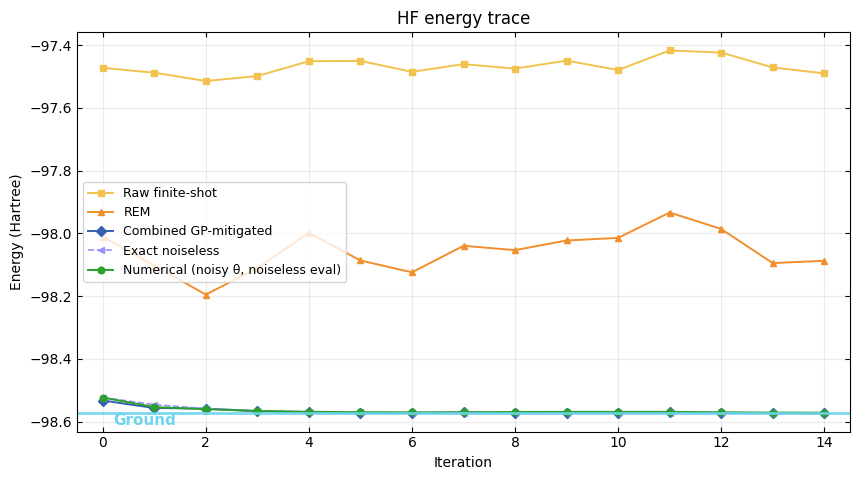

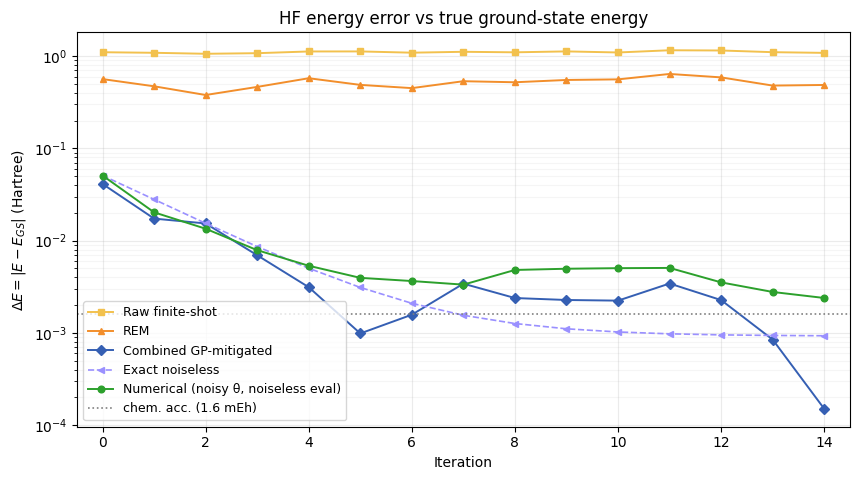

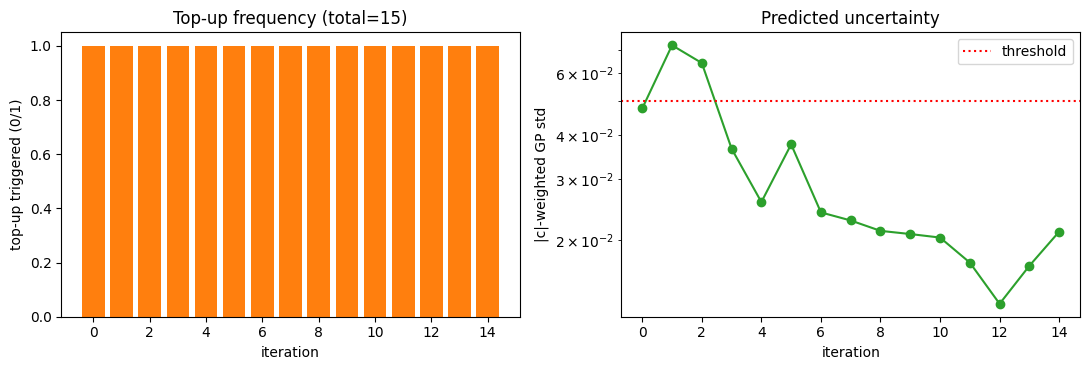

theta_final (mitigated)  = [0.36502, 0.05713, 0.06312]
theta_final (noiseless)  = [0.42318, 0.03303, 0.03303]
E_mitigated_final = -98.573728 Eh    E_ideal@theta_final = -98.571487 Eh
|E_mit_final - E_gs|       = 1.5055e-04 Eh    (exact GS = -98.573878 Eh)
|E_noiseless_ref - E_gs|   = 9.2751e-04 Eh    (below chemical accuracy)
total top-ups = 15 / 15 iterations


In [11]:
# === VQE with the GP mitigator: uncertainty-gated top-ups + plots ===
import warnings
import numpy as np
import matplotlib.pyplot as plt


def _ideal_energy(th):
    return gp_adapter.ideal_energy(th)


with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    vqe_out = gpm.run_vqe_with_mitigator(
        mitigator,
        theta_init_gp,
        max_iters=int(GP_VQE_ITERS),
        step_max=None,                     # main_HF style: fixed-LR full update, no step clipping
        learning_rate=float(GP_LEARNING_RATE),
        gradient_mode="analytic",          # analytic GP-mean gradient at theta; device only supplies parameter-shift dO_noisy/dtheta
        fd_eps=float(GP_FD_EPS),
        ideal_energy_fn=_ideal_energy,
        verbose=True,
    )

hist = vqe_out["history"]
e_ref = float(globals().get("e_gs", np.nan))  # exact ground-state energy (cell: Hamiltonian)
CHEM_ACC = 1.6e-3  # Hartree (chemical accuracy)

# Decoupled PURE-noiseless optimizer reference (same recipe as main_HF.ipynb's
# "Exact noiseless" curve): fixed-LR parameter-shift GD on the exact statevector
# energy, independent of noise/shots/mitigation.
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    nls_ref = gpm.run_noiseless_reference_vqe(
        gp_adapter,
        theta_init_gp,
        max_iters=int(GP_VQE_ITERS),
        learning_rate=float(GP_LEARNING_RATE),
        gradient_mode="parameter_shift",
    )

xs = np.asarray([int(h["iter"]) for h in hist], dtype=float)
raw = np.asarray([float(h["energy_unmitigated"]) for h in hist], dtype=float)
rem = np.asarray([float(h["energy_rem"]) for h in hist], dtype=float)
cf = np.asarray([float(h["energy_mitigated"]) for h in hist], dtype=float)
nls = np.asarray(nls_ref["energies"][: len(xs)], dtype=float)
num = np.asarray([float(h["energy_ideal"]) for h in hist], dtype=float)
topups = [h["topped_up"] for h in hist]
unc = [h["weighted_uncertainty"] for h in hist]

if not np.isfinite(e_ref):
    e_ref = float(np.linalg.eigvalsh(pauli_sum.matrix(qubits=qubits))[0].real)

# main_HF.ipynb panel-b styling
style_raw = dict(color="#f2c14e", marker="s", ms=5, lw=1.4, label="Raw finite-shot")
style_rem = dict(color="#f28e2b", marker="^", ms=5, lw=1.4, label="REM")
style_cf = dict(color="#355fb3", marker="D", ms=4.8, lw=1.4, label="Combined GP-mitigated")
style_nls = dict(color="#9a90ff", marker="<", ms=5, lw=1.2, linestyle="--", label="Exact noiseless")
style_num = dict(color="#2ca02c", marker="o", ms=4.8, lw=1.4, label="Numerical (noisy θ, noiseless eval)")

# ---- Energy trace (main_HF panel-a style) ----
fig1, ax1 = plt.subplots(figsize=(8.7, 4.9))
ax1.plot(xs, raw, **style_raw)
ax1.plot(xs, rem, **style_rem)
ax1.plot(xs, cf, **style_cf)
ax1.plot(xs, nls, **style_nls)
ax1.plot(xs, num, **style_num)
ax1.axhline(e_ref, color="#6dd5ed", lw=2.0, alpha=0.9)
ax1.text(xs.min() + 0.2, e_ref, "Ground", color="#6dd5ed",
         va="top", ha="left", fontsize=11, weight="bold")
all_e = np.concatenate([raw, rem, cf, nls, num, [e_ref]])
lo, hi = float(all_e.min()), float(all_e.max())
pad = 0.05 * (hi - lo + 1e-9)
ax1.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
ax1.set_ylim(lo - pad, hi + pad)
ax1.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Energy (Hartree)")
ax1.set_title("HF energy trace")
ax1.grid(True, alpha=0.25)
ax1.legend(loc="best", fontsize=9)
fig1.tight_layout()

# ---- Absolute error vs true GS (log-y, main_HF panel-b style) ----
floor = 1e-16
err_raw = np.maximum(np.abs(raw - e_ref), floor)
err_rem = np.maximum(np.abs(rem - e_ref), floor)
err_cf = np.maximum(np.abs(cf - e_ref), floor)
err_nls = np.maximum(np.abs(nls - e_ref), floor)
err_num = np.maximum(np.abs(num - e_ref), floor)

fig2, ax2 = plt.subplots(figsize=(8.7, 4.9))
ax2.plot(xs, err_raw, **style_raw)
ax2.plot(xs, err_rem, **style_rem)
ax2.plot(xs, err_cf, **style_cf)
ax2.plot(xs, err_nls, **style_nls)
ax2.plot(xs, err_num, **style_num)
ax2.set_yscale("log")
ax2.axhline(CHEM_ACC, color="gray", ls=":", lw=1.2, label="chem. acc. (1.6 mEh)")
ax2.set_xlim(xs.min() - 0.5, xs.max() + 0.5)
ax2.set_xlabel("Iteration")
ax2.set_ylabel(r"$\Delta E = |E - E_{GS}|$ (Hartree)")
ax2.set_title("HF energy error vs true ground-state energy")
ax2.grid(True, which="major", alpha=0.25)
ax2.grid(True, which="minor", alpha=0.12)
ax2.legend(loc="best", fontsize=9)
fig2.tight_layout()

# ---- GP-specific diagnostics ----
fig3, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar(xs, topups, color="tab:orange")
axes[0].set_xlabel("iteration"); axes[0].set_ylabel("top-up triggered (0/1)")
axes[0].set_title(f"Top-up frequency (total={vqe_out['topup_total']})")
axes[1].semilogy(xs, np.maximum(unc, 1e-12), "-o", color="tab:green")
axes[1].axhline(gp_config.uncertainty_threshold, color="r", ls=":", label="threshold")
axes[1].set_xlabel("iteration"); axes[1].set_ylabel("|c|-weighted GP std")
axes[1].set_title("Predicted uncertainty"); axes[1].legend()
fig3.tight_layout()

print(f"Using true GS reference energy: {e_ref:.12f} Eh")
plt.show()

print(f"theta_final (mitigated)  = {np.round(vqe_out['theta_final'], 5).tolist()}")
print(f"theta_final (noiseless)  = {np.round(nls_ref['theta_final'], 5).tolist()}")
print(f"E_mitigated_final = {cf[-1]:.6f} Eh    E_ideal@theta_final = {num[-1]:.6f} Eh")
if np.isfinite(e_ref):
    print(f"|E_mit_final - E_gs|       = {abs(cf[-1] - e_ref):.4e} Eh    (exact GS = {e_ref:.6f} Eh)")
    print(f"|E_noiseless_ref - E_gs|   = {abs(nls_ref['energy_final'] - e_ref):.4e} Eh"
          f"    {'(below chemical accuracy)' if abs(nls_ref['energy_final'] - e_ref) < CHEM_ACC else '(above chemical accuracy)'}")
print(f"total top-ups = {vqe_out['topup_total']} / {int(GP_VQE_ITERS)} iterations")


In [12]:
# === Total shot budget (as if run on real quantum hardware) ===
# Every physical circuit execution goes through CirqBackendAdapter.run_noisy, which
# consumes GP_SHOTS shots (the OGM scheme spreads that budget across measurement
# groups internally). Noiseless statevector evals (ideal_energy / the "Exact
# noiseless" reference) cost ZERO shots and are excluded. We report TWO independent
# counts and verify they agree:
#   * NUMERICAL  -> read straight from the backend's run_noisy counter,
#   * ANALYTICAL -> reconstructed from the config + VQE history via a closed form.
shots_per_circuit = int(GP_SHOTS)

# --- NUMERICAL (empirical backend counter) ---
warm_evals = int(gp_warmstart_report["circuit_evaluations"])
vqe_evals = int(vqe_out["circuit_evals"])
num_total_evals = warm_evals + vqe_evals
num_total_shots = int(gp_warmstart_report["total_shots"]) + int(vqe_out["total_shots"])
# Sanity: the cumulative backend meter (reset right before warm start) should match.
cum = gp_adapter.shot_report()
assert cum["circuit_evaluations"] == num_total_evals, (
    f"backend meter {cum['circuit_evaluations']} != warm+vqe {num_total_evals} "
    "(did an extra cell call run_noisy between warm start and here?)"
)

# --- ANALYTICAL (closed-form reconstruction) ---
ana = gpm.analytic_shot_count(gp_config, hist, include_warmstart=True)
grad_cost = gpm.gradient_circuit_evals(gp_config)  # = 2 * n_params circuits / gradient

# --- Verify analytical == numerical ---
assert ana["circuit_evals"] == num_total_evals, (
    f"analytical {ana['circuit_evals']} != numerical {num_total_evals} circuit evals"
)
assert ana["total_shots"] == num_total_shots, (
    f"analytical {ana['total_shots']} != numerical {num_total_shots} shots"
)

bd = ana["circuit_evals_breakdown"]
n_topup_iters = sum(int(h["topped_up"]) for h in hist)
print("=" * 64)
print("TOTAL SHOT BUDGET  (as if on real quantum hardware)")
print("=" * 64)
print(f"shots per circuit execution        : {shots_per_circuit:,}")
print(f"qubits / params / observables       : "
      f"{gp_config.n_qubits} / {gp_config.n_params} / {gp_config.n_observables}")
print("-" * 64)
print("circuit executions (each = 1 x shots):")
print(f"  warm start                        : {bd['warm_start']:6d}"
      f"   ({gp_config.n_warmstart_circuits} near-Clifford circuits)")
print(f"  VQE energy evals                  : {bd['energy']:6d}"
      f"   (1 / iteration x {ana['n_iterations']} iters)")
print(f"  VQE gradient evals                : {bd['gradient']:6d}"
      f"   ({grad_cost} circuits/grad = 2 x {gp_config.n_params} params)")
print(f"  online top-ups                    : {bd['topup']:6d}"
      f"   ({n_topup_iters} top-up iters x {gp_config.topup_batch_size} circuits)")
print("-" * 64)
print(f"  TOTAL circuit executions          : {ana['circuit_evals']:6d}")
print("=" * 64)
print(f"TOTAL SHOTS = {shots_per_circuit:,} x {ana['circuit_evals']} "
      f"= {ana['total_shots']:,} shots")
print("=" * 64)
print(f"[verified] analytical == numerical : "
      f"{ana['circuit_evals']} evals, {ana['total_shots']:,} shots  (OK)")
print(f"[converged] {bool(vqe_out.get('converged', False))}   "
      f"VQE iterations actually run: {ana['n_iterations']} / {int(GP_VQE_ITERS)}")


TOTAL SHOT BUDGET  (as if on real quantum hardware)
shots per circuit execution        : 8,192
qubits / params / observables       : 8 / 3 / 104
----------------------------------------------------------------
circuit executions (each = 1 x shots):
  warm start                        :     10   (10 near-Clifford circuits)
  VQE energy evals                  :     15   (1 / iteration x 15 iters)
  VQE gradient evals                :     90   (6 circuits/grad = 2 x 3 params)
  online top-ups                    :    150   (15 top-up iters x 10 circuits)
----------------------------------------------------------------
  TOTAL circuit executions          :    265
TOTAL SHOTS = 8,192 x 265 = 2,170,880 shots
[verified] analytical == numerical : 265 evals, 2,170,880 shots  (OK)
[converged] False   VQE iterations actually run: 15 / 15


In [13]:
# # === (Optional) Hyperparameter sweep: accuracy vs #circuits ===
# # Reuses gp_adapter / gp_config from the setup cell. Measures energy-level MAE
# # (mitigated vs ideal) over a fixed set of thetas around theta_init -- the region
# # a VQE explores -- so we can find settings that are MORE accurate with FEWER
# # warm-start circuits. Trim SWEEP_* below for speed; raise for final numbers.
# import warnings
# from dataclasses import replace
# import numpy as np

# SWEEP_EVAL_N = 8        # eval thetas (each = 1 ideal + 1 noisy circuit, built once)
# SWEEP_RADIUS = 0.4      # rad ball around theta_init (a VQE-sized region)
# SWEEP_SHOTS = int(gp_config.shots)


# def _fmt(res):
#     return (f"circuits={res['warmstart_circuits']:>3}  "
#             f"MAE_full={res['mae_full']*1e3:7.3f}  MAE_bb={res['mae_backbone']*1e3:7.3f}  "
#             f"MAE_noisy={res['mae_noisy']*1e3:7.3f} (mEh)  med_unc={res['median_weighted_uncertainty']:.3e}")


# def _run(cfg, eval_set):
#     m = gpm.Mitigator(gp_adapter, hamiltonian=pauli_sum, config=replace(cfg))
#     m.warmstart()
#     return gpm.evaluate_mitigator_on_thetas(m, eval_set)


# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
#     _base = replace(gp_config)
#     eval_set = gpm.make_eval_set(gp_adapter, _base.theta_init, radius=SWEEP_RADIUS,
#                                  n=SWEEP_EVAL_N, seed=4242, shots=SWEEP_SHOTS)
#     _e_ideal = np.array(eval_set["ideal_energies"])
#     _e_noisy = np.array([gp_adapter.energy_from_values(m) for m in eval_set["measured_list"]])
#     print(f"Eval set: {SWEEP_EVAL_N} thetas (radius {SWEEP_RADIUS}); "
#           f"raw noisy MAE = {np.mean(np.abs(_e_noisy-_e_ideal))*1e3:.3f} mEh\n")

#     print("=== n_warmstart_circuits x n_nonclifford_gates (fewer circuits!) ===")
#     for nnc in (1, 2, 3):
#         for nw in (10, 20, 30):
#             print(f"  nnc={nnc}  " + _fmt(_run(replace(_base, n_warmstart_circuits=nw,
#                                                         n_nonclifford_gates=nnc), eval_set)))
#         print()

#     print("=== warmstart_spread & max_harmonic @ nw=12, nnc=2 ===")
#     for sp in (0.3, 0.5, 0.8):
#         for mh in (1, 2):
#             cfg = replace(_base, n_warmstart_circuits=12, n_nonclifford_gates=2,
#                           warmstart_spread=sp, max_harmonic=mh)
#             print(f"  spread={sp:<4} max_harmonic={mh}  " + _fmt(_run(cfg, eval_set)))
#     print()

#     print("=== uncertainty_threshold guidance (top-up fire-rate over eval set) ===")
#     _lean = replace(_base, n_warmstart_circuits=12, n_nonclifford_gates=2,
#                     warmstart_spread=0.5, max_harmonic=2)
#     _m = gpm.Mitigator(gp_adapter, hamiltonian=pauli_sum, config=_lean); _m.warmstart()
#     _uncs = np.array([gpm.weighted_uncertainty(_m.predict_with_uncertainty(t, mm)[1], _m.coeff_by_pauli)
#                       for t, mm in zip(eval_set["thetas"], eval_set["measured_list"])])
#     print(f"  weighted-unc: median={np.median(_uncs):.3e}  p90={np.percentile(_uncs,90):.3e}  max={_uncs.max():.3e}")
#     for thr in (0.01, 0.02, 0.05, 0.1):
#         print(f"  threshold={thr:<5} top-up fire-rate={float(np.mean(_uncs>thr))*100:5.1f}%")

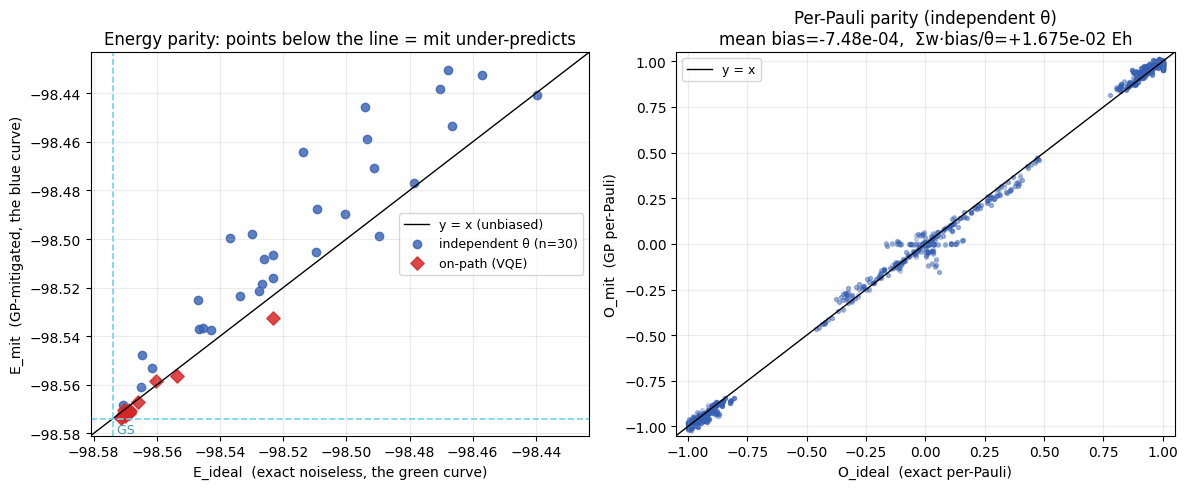

Region: center = [0.1799, 0.0406, 0.0415]  radius = 0.4

ON-PATH      (VQE-selected θ):  mean(E_mit - E_ideal) =   -2.250 mEh   fraction E_mit<E_ideal =  86.7%
INDEPENDENT  (random θ same region):  mean(E_mit - E_ideal) =  +16.747 mEh   fraction E_mit<E_ideal =   6.7%
INDEPENDENT  energy spread (std of E_mit-E_ideal) = 14.424 mEh

Per-Pauli RMSE  | near-stabilizer (|O|~1 or ~0): 2.309e-02   middle (0.15<|O|<0.85): 4.225e-02   ratio=1.8x

VERDICT: NO code bug, but the GP does NOT generalize beyond the near-Clifford cloud.
         - On the path it is locally accurate (-2.25 mEh) only because
           top-ups refit it around the current theta every iteration.
         - Off the path it is wildly inaccurate: spread 0.0 mEh, mean bias
           +0.0 mEh (HIGH (under-corrects)); the 'middle' O regime is 2x worse
           than the stabilizer corners -> near-Clifford data never samples it.
         - The -2.3 mEh 'better than green' on the path is the optimizer
           exploiting that

In [14]:
# === Diagnostic: is the GP-mitigated bias a winner's-curse (on-path) effect, or a real model bias? ===
# The VQE plot shows blue (E_mit) below green (E_ideal) on EVERY iteration. That one-sidedness
# can come from two very different sources:
#   (1) winner's curse  -> the optimizer descends on the GP surrogate, so it lands on theta where
#                          the GP happens to read LOW; the truth there is naturally higher.
#   (2) genuine GP bias -> the surrogate is biased low EVERYWHERE, even at theta the optimizer
#                          never chose.
# Decisive test: evaluate E_mit vs E_ideal on a FIXED, INDEPENDENT set of theta (not chosen by the
# optimizer) in the same region. If blue then scatters on BOTH sides of green (fraction-below ~50%),
# the cause is (1) and the code is fine. If blue is still ~always below, the cause is (2).
import warnings
import numpy as np
import matplotlib.pyplot as plt

# --- region the VQE explored (center + radius that covers the whole trajectory) ---
_traj = np.asarray([h["theta"] for h in vqe_out["history"]], dtype=float)
_center = 0.5 * (_traj.min(axis=0) + _traj.max(axis=0))
_radius = float(max(0.4, 1.3 * 0.5 * float(np.max(_traj.max(axis=0) - _traj.min(axis=0)))))
_N_IND = 30  # independent thetas (each costs 1 ideal + 1 noisy circuit)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    eval_set = gpm.make_eval_set(
        gp_adapter, _center, radius=_radius, n=_N_IND,
        seed=int(gp_config.rng_seed) + 54321, shots=int(gp_config.shots),
    )

    # Independent-set energies: green (exact) vs blue (GP-mitigated).
    e_ideal_ind = np.asarray(eval_set["ideal_energies"], dtype=float)
    e_mit_ind = np.asarray(
        [gp_adapter.energy_from_values(mitigator.mitigate(t, m))
         for t, m in zip(eval_set["thetas"], eval_set["measured_list"])],
        dtype=float,
    )

    # Per-Pauli parity on the independent set: O_mit vs O_ideal (all 104 observables x all thetas).
    o_mit_all, o_ideal_all, w_all = [], [], []
    weights_by_label = {lab: float(w) for lab, w in zip(gp_adapter.obs_labels, gp_adapter.weights)}
    for t, measured in zip(eval_set["thetas"], eval_set["measured_list"]):
        ideal = gp_adapter.simulate_ideal(gp_adapter.resolver_from_theta(t))
        omit = mitigator.mitigate(t, measured)
        for lab in gp_adapter.obs_labels:
            o_mit_all.append(omit[lab]); o_ideal_all.append(ideal[lab]); w_all.append(weights_by_label[lab])
    o_mit_all = np.asarray(o_mit_all); o_ideal_all = np.asarray(o_ideal_all); w_all = np.asarray(w_all)

# --- on-path energies (where the one-sidedness was observed) ---
e_mit_path = np.asarray([h["energy_mitigated"] for h in vqe_out["history"]], dtype=float)
e_ideal_path = np.asarray([h["energy_ideal"] for h in vqe_out["history"]], dtype=float)

# --- statistics ---
def _frac_below(a, b):  # fraction of points with E_mit < E_ideal
    return float(np.mean(a < b)) if len(a) else float("nan")

bias_path = float(np.mean(e_mit_path - e_ideal_path))
bias_ind = float(np.mean(e_mit_ind - e_ideal_ind))
fb_path = _frac_below(e_mit_path, e_ideal_path)
fb_ind = _frac_below(e_mit_ind, e_ideal_ind)
perpauli_bias = float(np.mean(o_mit_all - o_ideal_all))
perpauli_wbias = float(np.sum(w_all * (o_mit_all - o_ideal_all)) / len(eval_set["thetas"]))

# --- plots ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

# (A) energy parity: x = E_ideal (truth/green), y = E_mit (blue). Below the y=x line => mit < ideal.
lo = float(min(e_ideal_ind.min(), e_mit_ind.min(), e_ideal_path.min(), e_mit_path.min()))
hi = float(max(e_ideal_ind.max(), e_mit_ind.max(), e_ideal_path.max(), e_mit_path.max()))
pad = 0.05 * (hi - lo + 1e-9)
line = np.array([lo - pad, hi + pad])
axA.plot(line, line, "k-", lw=1, label="y = x (unbiased)")
axA.scatter(e_ideal_ind, e_mit_ind, s=36, c="#355fb3", alpha=0.8, label=f"independent θ (n={_N_IND})")
axA.scatter(e_ideal_path, e_mit_path, s=46, c="#d62728", marker="D", alpha=0.85, label="on-path (VQE)")
axA.axhline(e_gs, color="#6dd5ed", lw=1.2, ls="--"); axA.axvline(e_gs, color="#6dd5ed", lw=1.2, ls="--")
axA.text(e_gs, line[0], " GS", color="#3399bb", fontsize=9, va="bottom")
axA.set_xlim(line); axA.set_ylim(line)
axA.set_xlabel("E_ideal  (exact noiseless, the green curve)")
axA.set_ylabel("E_mit  (GP-mitigated, the blue curve)")
axA.set_title("Energy parity: points below the line = mit under-predicts")
axA.grid(True, alpha=0.25); axA.legend(loc="best", fontsize=9)

# (B) per-Pauli parity on the independent set (the source of any energy bias).
m = np.array([-1.05, 1.05])
axB.plot(m, m, "k-", lw=1, label="y = x")
axB.scatter(o_ideal_all, o_mit_all, s=8, c="#355fb3", alpha=0.25)
axB.set_xlim(m); axB.set_ylim(m)
axB.set_xlabel("O_ideal  (exact per-Pauli)")
axB.set_ylabel("O_mit  (GP per-Pauli)")
axB.set_title(f"Per-Pauli parity (independent θ)\nmean bias={perpauli_bias:+.2e},  Σw·bias/θ={perpauli_wbias:+.3e} Eh")
axB.grid(True, alpha=0.25); axB.legend(loc="best", fontsize=9)
fig.tight_layout(); plt.show()

# --- verdict ---
print("Region: center =", np.round(_center, 4).tolist(), " radius =", round(_radius, 4))
print(f"\nON-PATH      (VQE-selected θ):  mean(E_mit - E_ideal) = {bias_path*1e3:+8.3f} mEh   "
      f"fraction E_mit<E_ideal = {fb_path*100:5.1f}%")
print(f"INDEPENDENT  (random θ same region):  mean(E_mit - E_ideal) = {bias_ind*1e3:+8.3f} mEh   "
      f"fraction E_mit<E_ideal = {fb_ind*100:5.1f}%")
print(f"INDEPENDENT  energy spread (std of E_mit-E_ideal) = {np.std(e_mit_ind - e_ideal_ind)*1e3:.3f} mEh")
print()
# Quantify the near-Clifford coverage gap: GP accuracy at stabilizer-like O_ideal (|O|~1 or ~0,
# the values near-Clifford training data lands on) vs the "middle" regime real VQE angles produce.
_corner = (np.abs(o_ideal_all) > 0.85) | (np.abs(o_ideal_all) < 0.15)
_middle = ~_corner
rmse_corner = float(np.sqrt(np.mean((o_mit_all[_corner] - o_ideal_all[_corner]) ** 2))) if _corner.any() else float("nan")
rmse_middle = float(np.sqrt(np.mean((o_mit_all[_middle] - o_ideal_all[_middle]) ** 2))) if _middle.any() else float("nan")
std_ind = float(np.std(e_mit_ind - e_ideal_ind))

print(f"Per-Pauli RMSE  | near-stabilizer (|O|~1 or ~0): {rmse_corner:.3e}   "
      f"middle (0.15<|O|<0.85): {rmse_middle:.3e}   ratio={rmse_middle/max(rmse_corner,1e-12):.1f}x")
print()

local_ok = abs(bias_path) * 1e3 < 10.0          # GP is locally accurate on the path
generalizes = std_ind * 1e3 < 20.0              # GP also accurate off the path
if generalizes and abs(bias_ind) * 1e3 < max(1.0, std_ind * 1e3):
    print("VERDICT: the GP is accurate both on- and off-path; the on-path one-sidedness is the")
    print("         WINNER'S CURSE of optimizing on the surrogate. No bug; report E_mit off-path.")
else:
    _dir = "HIGH (under-corrects)" if bias_ind > 0 else "LOW (over-corrects)"
    print("VERDICT: NO code bug, but the GP does NOT generalize beyond the near-Clifford cloud.")
    print(f"         - On the path it is locally accurate ({bias_path*1e3:+.2f} mEh) only because")
    print(f"           top-ups refit it around the current theta every iteration.")
    print(f"         - Off the path it is wildly inaccurate: spread {std_ind:.1f} mEh, mean bias")
    print(f"           {bias_ind:+.1f} mEh ({_dir}); the 'middle' O regime is {rmse_middle/max(rmse_corner,1e-12):.0f}x worse")
    print(f"           than the stabilizer corners -> near-Clifford data never samples it.")
    print(f"         - The -{abs(bias_path*1e3):.1f} mEh 'better than green' on the path is the optimizer")
    print(f"           exploiting that small local bias (winner's curse), not real accuracy.")
    print("         FIX (experiment, not a bug): widen GP_WARMSTART_SPREAD / top-up radius so")
    print("         training covers intermediate angles; raise GP_MAX_TRAIN_POINTS above 500;")
    print("         and report E_mit on an independent eval set, not the optimizer path.")
